In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [109]:
# Parámetros de la simulación
R = 1.0  # Radio de la rueda
v = 1.0  # velocidad lineal constante
omega = 0.5  # velocidad angular constante

In [119]:
# Ecuaciones diferenciales
def Sistema(state, t):
    x, y, theta, phi = state
    dx = v * np.cos(theta)
    dy = v * np.sin(theta)
    #omega = 0.5 * np.sin(1*t) # Aca cambiamos el modelo
    dtheta = omega
    dphi = v / R
    return [dx, dy, dtheta, dphi]

In [123]:
# Tiempo de integración
t = np.linspace(0, 15, 70)
# condiciones iniciales
y0 = np.array([0, 0, np.pi/3, 0])
# Integrador
sol = odeint(Sistema, y0, t)
x = sol[:, 0]
y = sol[:, 1]
theta = sol[:, 2]
phi = sol[:, 3]

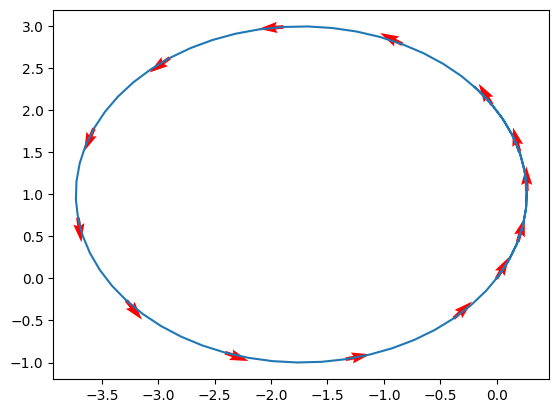

In [124]:
plt.plot(x, y)
plt.quiver(x[::5], y[::5], np.cos(theta[::5]), np.sin(theta[::5]),
           scale=20, color='r', label='Orientación')

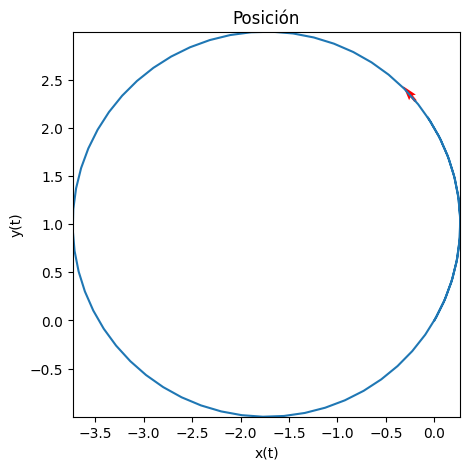

In [125]:
# Animation
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

def init():
  ax.set_xlim(min(x), max(x))
  ax.set_ylim(min(y), max(y))
  ax.set_xlabel('x(t)')
  ax.set_ylabel('y(t)')
  ax.set_title('Posición')


def Update(i):
  ax.clear()
  init()

  ax.plot(x[:i], y[:i])
  ax.quiver(x[i], y[i], np.cos(theta[i]), np.sin(theta[i]),
           scale=20, color='r', label='Orientación')

  return []

# Crear animación
ani = FuncAnimation(fig, Update, frames=len(t), init_func=init)

# Mostrar en Colab
HTML(ani.to_jshtml())